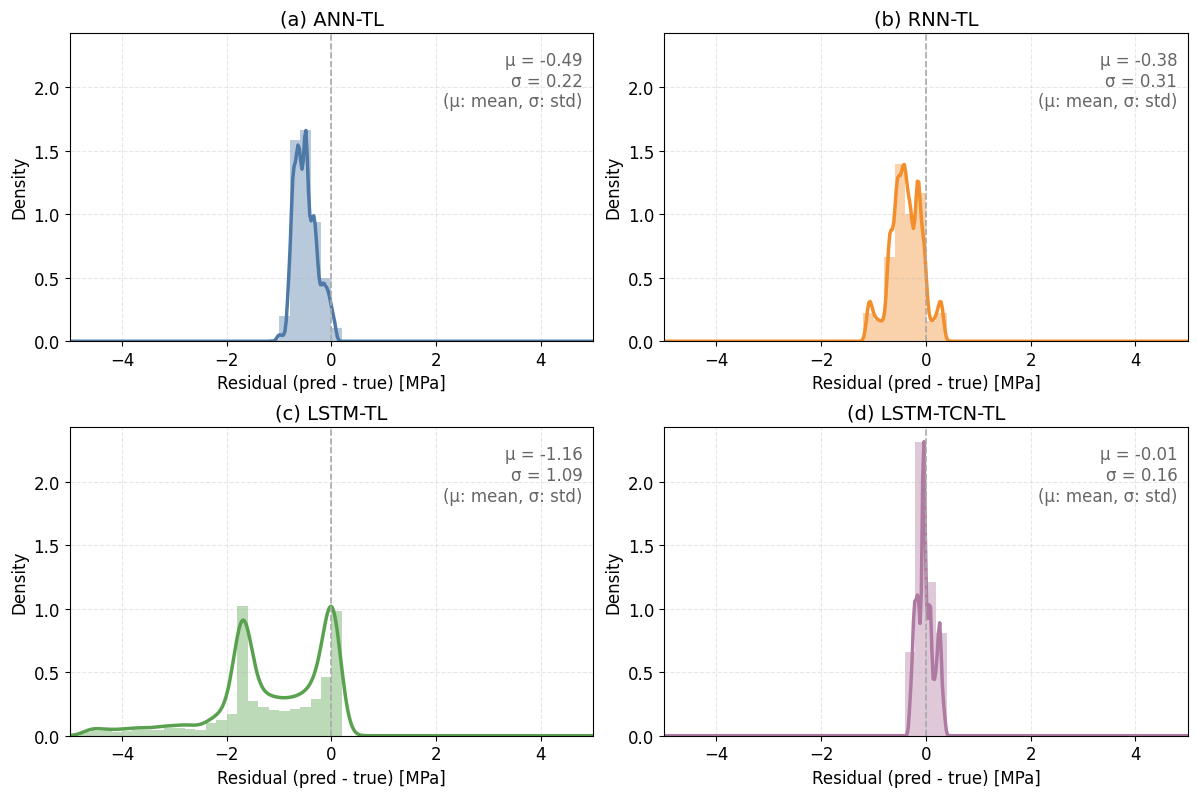

saved: tl_ann_fig/prediction/hist_residuals_TL_2x2_styled_density_kde.png


In [14]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 样式参数（可改）
BINS        = 50
HIST_RANGE  = (-5, 5)   # None 则自适应
DENSITY     = True      # 直方图画密度；KDE 与其自然对齐
ALPHA_BAR   = 0.40      # 柱填充透明度（弱化柱子）
LINE_ZERO   = {'color':'#A9A9A9', 'linestyle':'--', 'linewidth':1.2}
COLORS      = {'ANN-TL':'#4E79A7','RNN-TL':'#F28E2B','LSTM-TL':'#59A14F','LSTM-TCN-TL':'#AF7AA1'}
LABELS      = ['(a) ANN-TL','(b) RNN-TL','(c) LSTM-TL','(d) LSTM-TCN-TL']

series = [
    {'name': 'ANN-TL',      'csv': 'tl_ann_fig/prediction/residuals_ANN_TL.csv'},
    {'name': 'RNN-TL',      'csv': 'tl_rnn_fig/prediction/residuals_RNN_TL.csv'},
    {'name': 'LSTM-TL',     'csv': 'tl_lstm_fig/prediction/residuals_LSTM_TL.csv'},
    {'name': 'LSTM-TCN-TL', 'csv': 'lstmtcn_tl_fig/prediction/residuals_LSTMTCN_TL.csv'},
]

# 2×2 子图，Y 轴对齐
nrows, ncols = 2, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8), sharey=True)
axes = axes.ravel()

for idx, (ax, s) in enumerate(zip(axes, series)):
    df = pd.read_csv(s['csv']).dropna()
    res = df['residual'].values.astype(float)

    # 直方图（密度）
    hist_vals, bin_edges, _ = ax.hist(
        res, bins=BINS, range=HIST_RANGE, density=DENSITY,
        color=COLORS[s['name']], alpha=ALPHA_BAR,
        edgecolor=COLORS[s['name']], linewidth=0.0
    )

    # KDE（密度）→ 按直方图密度峰值缩放，确保线“顶到”bar 顶端（包含 LSTM-TL）
    if len(res) >= 2:
        kde = gaussian_kde(res)  # 可调带宽：bw_method=0.8/1.2
        grid = np.linspace(HIST_RANGE[0], HIST_RANGE[1], 400) if HIST_RANGE else \
               np.linspace(res.min(), res.max(), 400)
        y_kde = kde(grid)
        scale = (hist_vals.max() / (y_kde.max() + 1e-12)) if hist_vals.size else 1.0
        ax.plot(grid, y_kde * scale, color=COLORS[s['name']], linewidth=2.5, label=s['name'])

    ax.axvline(0, **LINE_ZERO)

    mu    = np.mean(res)
    sigma = np.std(res, ddof=1) if len(res) > 1 else 0.0
    ax.text(0.98, 0.94, f'μ = {mu:.2f}\nσ = {sigma:.2f}\n(μ: mean, σ: std)',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=12, color='#666666')

    ax.set_title(LABELS[idx], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=12)
    ax.tick_params(axis='y', which='both', left=True, labelleft=True)  # 显示右列刻度文字
    ax.set_ylabel('Density', fontsize=12)
    ax.set_xlabel('Residual (pred - true) [MPa]', fontsize=12)
    if HIST_RANGE is not None:
        ax.set_xlim(*HIST_RANGE)

plt.tight_layout(pad=0.8)
os.makedirs('tl_ann_fig/prediction', exist_ok=True)
out_path = os.path.join('tl_ann_fig', 'prediction', 'hist_residuals_TL_2x2_styled_density_kde.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print('saved:', out_path)